In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()


PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
METADATA_DIR = PROJECT_ROOT / "dataset"
METADATA_CSV = METADATA_DIR / "metadata.csv"

In [5]:
pd.set_option("display.max_columns", None)

In [9]:
df_metadata = pd.read_csv(METADATA_CSV)
df_metadata.head(20)

,timestamp,relative_filepath,fractal_type,colormap,width,height,max_iter,depth,bounds_xmin,bounds_xmax,bounds_ymin,bounds_ymax,score,inside_ratio,boundary_present,fractal_dimension,entropy,std,edge_density,dim_score,entropy_score,variance_score,edge_score
0,2026-06-16T20:16:54.521599,mandelbrot/1024_1024_iter1024/260616201654_mag...,mandelbrot,magma,1024,1024,1024,2,-0.080000,0.040000,-1.020000,-0.900000,0.409631,0.001400,True,1.535966,1.649634,9.554566,0.001125,0.880114,0.329927,0.095546,0.000000
1,2026-06-16T20:17:09.213368,mandelbrot/1024_1024_iter1024/260616201709_mag...,mandelbrot,magma,1024,1024,1024,4,-0.046400,-0.041600,-0.986400,-0.981600,0.407460,0.350050,True,1.777409,3.622076,116.623269,0.016925,0.075304,0.724415,1.000000,0.000000
2,2026-06-16T20:17:17.556361,mandelbrot/1024_1024_iter1024/260616201717_mag...,mandelbrot,magma,1024,1024,1024,5,-0.046400,-0.045440,-0.985440,-0.984480,0.614088,0.196975,True,1.642605,4.733486,95.666945,0.032575,0.524649,0.946697,0.956669,0.012262
3,2026-06-16T20:17:25.495909,mandelbrot/1024_1024_iter1024/260616201725_mag...,mandelbrot,magma,1024,1024,1024,6,-0.046208,-0.046016,-0.984864,-0.984672,0.518611,0.001300,True,1.573184,4.582033,12.445868,0.001775,0.756052,0.916407,0.124459,0.000000
4,2026-06-16T20:17:32.724406,mandelbrot/1024_1024_iter1024/260616201732_mag...,mandelbrot,magma,1024,1024,1024,7,-0.046208,-0.046170,-0.984749,-0.984710,0.426461,0.000175,True,1.622606,4.123985,6.650617,0.000375,0.591315,0.824797,0.066506,0.000000
5,2026-06-16T20:17:40.137524,mandelbrot/1024_1024_iter1024/260616201740_mag...,mandelbrot,magma,1024,1024,1024,8,-0.046177,-0.046170,-0.984741,-0.984733,0.542204,0.003975,True,1.554110,4.437022,16.740621,0.002075,0.819632,0.887404,0.167406,0.000000
6,2026-06-16T20:17:47.728982,mandelbrot/1024_1024_iter1024/260616201747_mag...,mandelbrot,magma,1024,1024,1024,9,-0.046177,-0.046176,-0.984735,-0.984733,0.719812,0.101325,True,1.489650,5.486709,65.943146,0.015875,0.965501,1.000000,0.659431,0.000000
7,2026-06-16T20:17:55.835524,mandelbrot/1024_1024_iter1024/260616201755_mag...,mandelbrot,magma,1024,1024,1024,10,-0.046177,-0.046177,-0.984735,-0.984735,0.614199,0.006675,True,1.533997,5.498853,26.931124,0.008400,0.886676,1.000000,0.269311,0.000000
8,2026-06-16T20:18:09.835208,mandelbrot/1024_1024_iter1024/260616201809_mag...,mandelbrot,magma,1024,1024,1024,2,-0.200000,-0.080000,-1.020000,-0.900000,0.464799,0.001100,True,1.519215,2.400400,8.598255,0.001175,0.935950,0.480080,0.085983,0.000000
9,2026-06-16T20:18:23.838269,mandelbrot/1024_1024_iter1024/260616201823_inf...,mandelbrot,inferno,1024,1024,1024,2,0.400000,0.520000,-0.420000,-0.300000,0.536338,0.013925,True,1.499696,2.527768,30.151957,0.005350,0.998988,0.505554,0.301520,0.000000


In [4]:
df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          3024 non-null   object 
 1   relative_filepath  3024 non-null   object 
 2   fractal_type       3024 non-null   object 
 3   colormap           3024 non-null   object 
 4   width              3024 non-null   int64  
 5   height             3024 non-null   int64  
 6   max_iter           3024 non-null   int64  
 7   depth              3024 non-null   int64  
 8   bounds_xmin        3024 non-null   float64
 9   bounds_xmax        3024 non-null   float64
 10  bounds_ymin        3024 non-null   float64
 11  bounds_ymax        3024 non-null   float64
 12  score              3024 non-null   float64
 13  inside_ratio       3024 non-null   float64
 14  boundary_present   3024 non-null   bool   
 15  fractal_dimension  3024 non-null   float64
 16  entropy            3024 

In [13]:
# drop boundary_present?
df_metadata["boundary_present"].value_counts()

boundary_present
True    3024
Name: count, dtype: int64

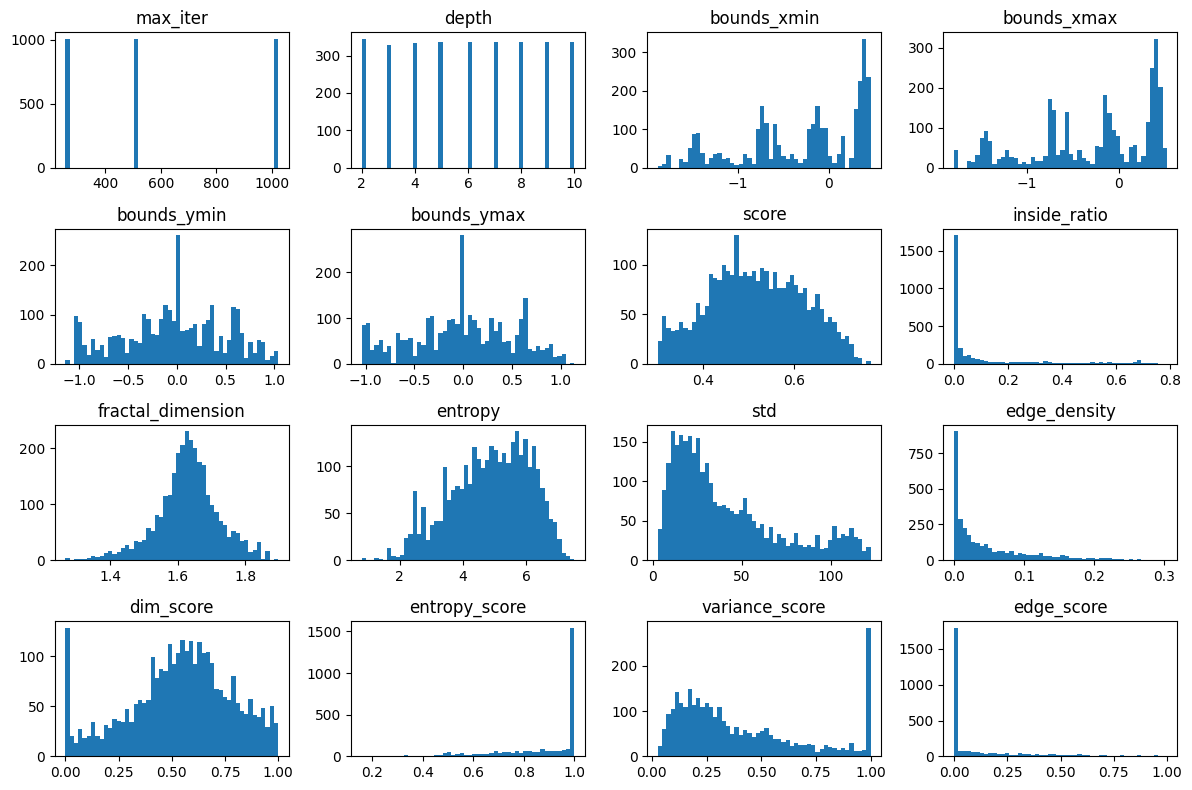

In [ ]:
df_metadata.drop(columns=["width", "height"]).hist(
    figsize=(12, 8),
    bins=50,
    grid=False,
)
plt.tight_layout()


In [ ]:
# Evaluator (Score) seems to somewhat reward deeper zoom (depth)
# and images with more "air" (inside ratio)

corr_score = df_metadata.corr(numeric_only=True)["score"]
corr_score

width                     NaN
height                    NaN
max_iter            -0.064032
depth                0.102577
bounds_xmin          0.005259
bounds_xmax         -0.007083
bounds_ymin         -0.028860
bounds_ymax         -0.044264
score                1.000000
inside_ratio        -0.185742
boundary_present          NaN
fractal_dimension   -0.405668
entropy              0.607556
std                  0.270196
edge_density         0.462882
dim_score            0.490622
entropy_score        0.581665
variance_score       0.307555
edge_score           0.439511
Name: score, dtype: float64